In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

num_registros = 1000

produtos = [
    ("Café Expresso", 5.0),
    ("Cappuccino", 8.0),
    ("Latte", 9.0),
    ("Mocha", 10.0),
    ("Chá", 6.0),
    ("Pão de Queijo", 4.5),
    ("Croissant", 7.0),
    ("Bolo Fatia", 6.5)
]

clientes = ["Ana", "João", "Maria", "Pedro", "Lucas", "Carla", "Juliana"]

formas_pagamento = ["Dinheiro", "Cartão Crédito", "Cartão Débito", "Pix"]

data_fim = datetime.now()
data_inicio = data_fim - timedelta(days=180)

dados = []

for i in range(num_registros):
    nome_produto, preco = random.choice(produtos)
    quantidade = random.randint(1, 4)

    delta = data_fim - data_inicio
    segundos = random.randint(0, int(delta.total_seconds()))
    data = data_inicio + timedelta(seconds=segundos)

    dados.append({
        "id_venda": i + 1,
        "data": data,
        "produto": nome_produto,
        "preco_unitario": preco,
        "quantidade": quantidade,
        "valor_total": round(preco * quantidade, 2),
        "forma_pagamento": random.choice(formas_pagamento),
        "cliente": random.choice(clientes)
    })

df = pd.DataFrame(dados)
df = df.sort_values("data").reset_index(drop=True)

print(df.head())
df = pd.DataFrame(dados)
df = df.sort_values("data").reset_index(drop=True)

   id_venda                       data     produto  preco_unitario  \
0       619 2025-11-05 04:31:55.510871  Cappuccino             8.0   
1       166 2025-11-05 11:56:21.510871  Cappuccino             8.0   
2       572 2025-11-05 20:12:29.510871   Croissant             7.0   
3       887 2025-11-06 01:46:39.510871       Latte             9.0   
4       115 2025-11-06 02:56:49.510871   Croissant             7.0   

   quantidade  valor_total forma_pagamento cliente  
0           1          8.0  Cartão Crédito   Pedro  
1           2         16.0             Pix   Pedro  
2           4         28.0  Cartão Crédito    João  
3           3         27.0   Cartão Débito   Pedro  
4           4         28.0   Cartão Débito   Maria  


In [33]:
df.to_csv("cafeteria_vendas.csv", index=False)

In [10]:
df.to_csv("/kaggle/working/cafeteria_vendas.csv", index=False)

In [34]:
df.describe()

,id_venda,data,preco_unitario,quantidade,valor_total
count,1000.000000,1000,1000.000000,1000.000000,1000.00000
mean,500.500000,2026-02-02 14:07:34.703154176,7.077000,2.542000,18.10050
min,1.000000,2025-11-05 01:38:55.046154,4.500000,1.000000,4.50000
25%,250.750000,2025-12-24 01:59:55.296154112,6.000000,2.000000,10.00000
50%,500.500000,2026-02-01 09:22:48.546153984,7.000000,3.000000,18.00000
75%,750.250000,2026-03-16 18:40:52.546153984,9.000000,4.000000,24.00000
max,1000.000000,2026-05-03 08:11:06.046154,10.000000,4.000000,40.00000
std,288.819436,NaN,1.803836,1.130271,9.64576


In [35]:
df.groupby("produto")["valor_total"].sum().sort_values(ascending=False)

produto
Latte            3420.0
Mocha            3380.0
Cappuccino       2520.0
Croissant        2359.0
Chá              1782.0
Bolo Fatia       1781.0
Café Expresso    1540.0
Pão de Queijo    1318.5
Name: valor_total, dtype: float64

In [13]:
df = pd.DataFrame(dados)
df["data"] = pd.to_datetime(df["data"])
df = df.sort_values("data").reset_index(drop=True)

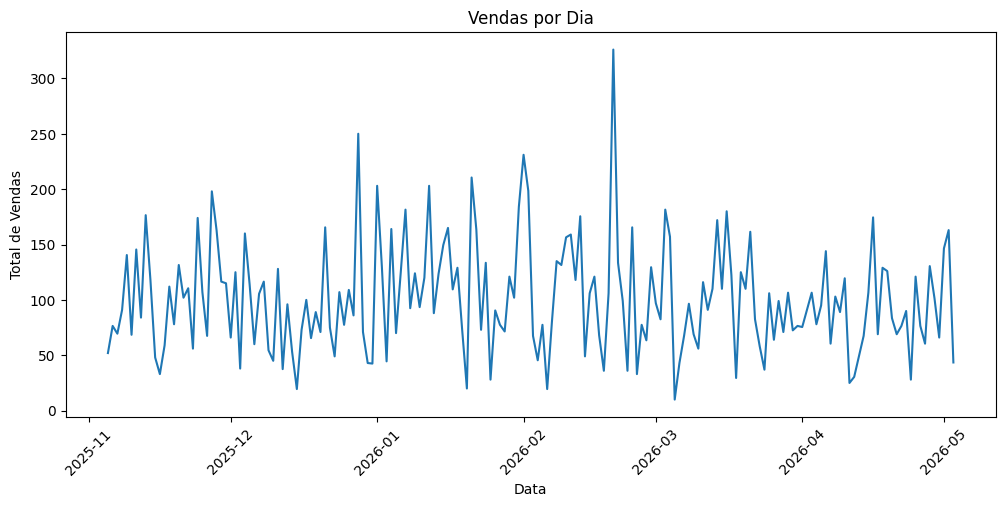

In [19]:
import matplotlib.pyplot as plt

vendas_dia = df.groupby(df["data"].dt.date)["valor_total"].sum()

plt.figure(figsize=(12,5))
vendas_dia.plot()
plt.title("Vendas por Dia")
plt.xlabel("Data")
plt.ylabel("Total de Vendas")
plt.xticks(rotation=45)
plt.show()

In [20]:
df["forma_pagamento"].value_counts()

forma_pagamento
Pix               259
Cartão Débito     252
Dinheiro          248
Cartão Crédito    241
Name: count, dtype: int64

In [21]:
df.groupby("produto")["quantidade"].sum().sort_values(ascending=False)

produto
Latte            380
Mocha            338
Croissant        337
Cappuccino       315
Café Expresso    308
Chá              297
Pão de Queijo    293
Bolo Fatia       274
Name: quantidade, dtype: int64

In [22]:
total_vendas = df["valor_total"].sum()
ticket_medio = df["valor_total"].mean()
total_pedidos = df["id_venda"].nunique()

print("💰 Faturamento total:", round(total_vendas, 2))
print("🧾 Ticket médio:", round(ticket_medio, 2))
print("📦 Total de pedidos:", total_pedidos)

💰 Faturamento total: 18100.5
🧾 Ticket médio: 18.1
📦 Total de pedidos: 1000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


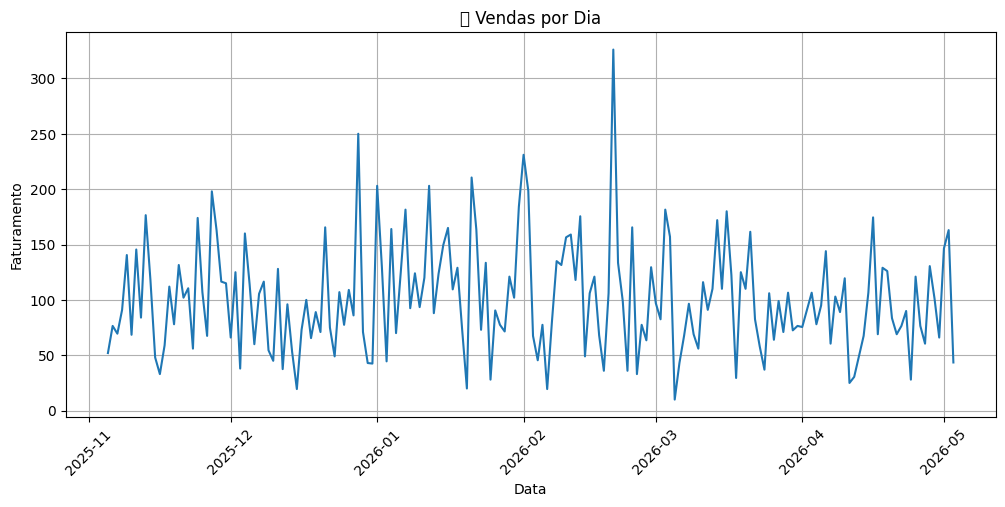

In [23]:
import matplotlib.pyplot as plt

vendas_dia = df.groupby(df["data"].dt.date)["valor_total"].sum()

plt.figure(figsize=(12,5))
plt.plot(vendas_dia.index, vendas_dia.values)
plt.title("📈 Vendas por Dia")
plt.xlabel("Data")
plt.ylabel("Faturamento")
plt.xticks(rotation=45)
plt.grid()
plt.show()

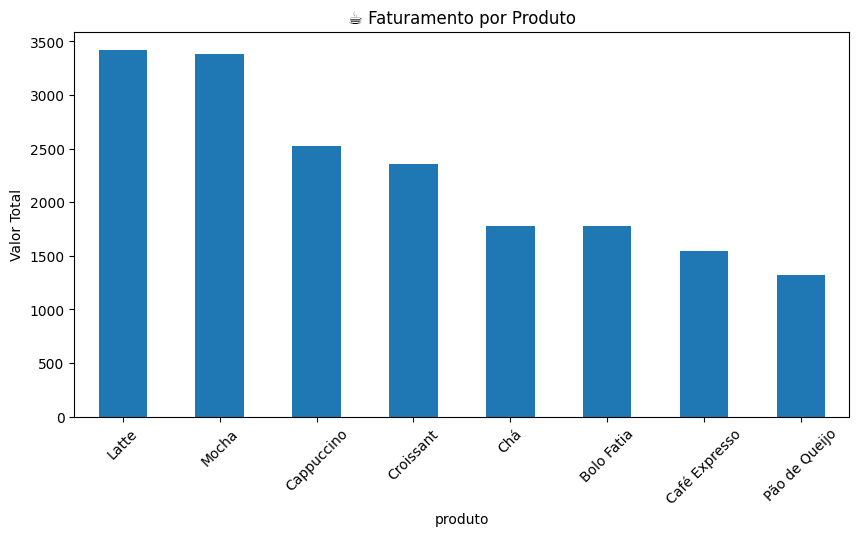

In [24]:
top_produtos = df.groupby("produto")["valor_total"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_produtos.plot(kind="bar")
plt.title("☕ Faturamento por Produto")
plt.ylabel("Valor Total")
plt.xticks(rotation=45)
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128179 (\N{CREDIT CARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


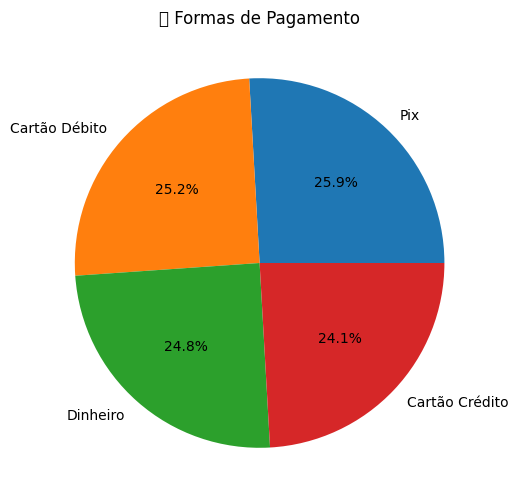

In [25]:
pagamentos = df["forma_pagamento"].value_counts()

plt.figure(figsize=(6,6))
pagamentos.plot(kind="pie", autopct="%1.1f%%")
plt.title("💳 Formas de Pagamento")
plt.ylabel("")
plt.show()

In [26]:
top_produto = top_produtos.index[0]
top_dia = vendas_dia.idxmax()
top_valor_dia = vendas_dia.max()

print("📊 INSIGHTS PRINCIPAIS")
print("-" * 30)
print(f"☕ Produto mais vendido: {top_produto}")
print(f"📅 Melhor dia de vendas: {top_dia}")
print(f"💰 Maior faturamento diário: {round(top_valor_dia, 2)}")

📊 INSIGHTS PRINCIPAIS
------------------------------
☕ Produto mais vendido: Latte
📅 Melhor dia de vendas: 2026-02-20
💰 Maior faturamento diário: 326.0


In [29]:
df["data"] = pd.to_datetime(df["data"])
df["hora"] = df["data"].dt.hour
df["dia_semana"] = df["data"].dt.day_name()
df["semana"] = df["data"].dt.isocalendar().week

In [31]:
import plotly.express as px

# Vendas por dia
vendas_dia = df.groupby(df["data"].dt.date)["valor_total"].sum().reset_index()
vendas_dia.columns = ["data", "vendas"]

fig = px.line(vendas_dia, x="data", y="vendas",
              title="📈 Vendas ao longo do tempo")
fig.show()

In [32]:
prod = df.groupby("produto")["valor_total"].sum().reset_index()

fig = px.bar(prod, x="produto", y="valor_total",
             title="☕ Faturamento por Produto",
             color="valor_total")
fig.show()

In [33]:
hora = df.groupby("hora")["valor_total"].sum().reset_index()

fig = px.line(hora, x="hora", y="valor_total",
              title="🕒 Vendas por Hora do Dia")
fig.show()

In [34]:
semana = df.groupby("dia_semana")["valor_total"].sum().reset_index()

fig = px.bar(semana, x="dia_semana", y="valor_total",
             title="📅 Vendas por Dia da Semana")
fig.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128302 (\N{CRYSTAL BALL}) missing from font(s) DejaVu Sans.



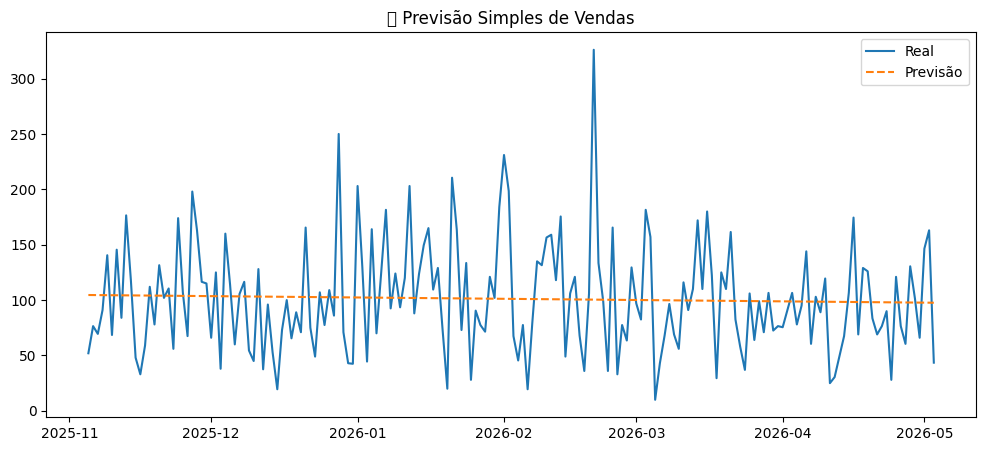

In [35]:
from sklearn.linear_model import LinearRegression
import numpy as np

# preparar dados
df_ml = df.groupby(df["data"].dt.date)["valor_total"].sum().reset_index()
df_ml["data"] = pd.to_datetime(df_ml["data"])
df_ml["dias"] = (df_ml["data"] - df_ml["data"].min()).dt.days

X = df_ml[["dias"]]
y = df_ml["valor_total"]

model = LinearRegression()
model.fit(X, y)

df_ml["previsao"] = model.predict(X)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_ml["data"], df_ml["valor_total"], label="Real")
plt.plot(df_ml["data"], df_ml["previsao"], label="Previsão", linestyle="--")
plt.legend()
plt.title("🔮 Previsão Simples de Vendas")
plt.show()

In [36]:
top_produto = df.groupby("produto")["valor_total"].sum().idxmax()
melhor_hora = df.groupby("hora")["valor_total"].sum().idxmax()
melhor_dia = df.groupby("dia_semana")["valor_total"].sum().idxmax()

print("📊 INSIGHTS PROFISSIONAIS")
print("-" * 40)
print(f"☕ Produto mais lucrativo: {top_produto}")
print(f"🕒 Horário de pico: {melhor_hora}h")
print(f"📅 Dia mais forte: {melhor_dia}")

📊 INSIGHTS PROFISSIONAIS
----------------------------------------
☕ Produto mais lucrativo: Latte
🕒 Horário de pico: 0h
📅 Dia mais forte: Thursday


# Coffee Shop Sales Analysis ☕
This project analyzes simulated sales data from a coffee shop.

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px

In [41]:
print("Top product:", ...)

Top product: Ellipsis


This project demonstrates skills in data analysis, visualization and basic machine learning.